In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [ ]:
df = pd.read_csv(story_summary.csv)

In [ ]:
df_test = df[df['split'].isin(['test-interpolation', 'test-extrapolation'])].copy()
df_test['split'] = df_test['split'].str.replace('test-', 'Test ').str.title()

def get_model_name(row):
        if row['method'] == 'mlp':
            return row['family']
        return row['method']
    
df_test['Model'] = df_test.apply(get_model_name, axis=1)

sns.set_theme(style="whitegrid", palette="Set2")

display(df_test.head())

,method,family,split,num_runs,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,Model
0,MeanBaseline,baseline,Test Extrapolation,3,0.262807,0.000000,0.303018,0.000000,-0.030171,0.000000,MeanBaseline
1,MeanBaseline,baseline,Test Interpolation,3,0.277203,0.000000,0.320281,0.000000,-0.002461,0.000000,MeanBaseline
4,PlanLengthBaseline,baseline,Test Extrapolation,3,0.551345,0.000000,0.641309,0.000000,-3.614319,0.000000,PlanLengthBaseline
5,PlanLengthBaseline,baseline,Test Interpolation,3,0.263914,0.000000,0.306298,0.000000,0.083161,0.000000,PlanLengthBaseline
8,mlp,ad_lstm_wl_delta,Test Extrapolation,3,0.184874,0.014019,0.250774,0.012221,0.292755,0.069256,ad_lstm_wl_delta


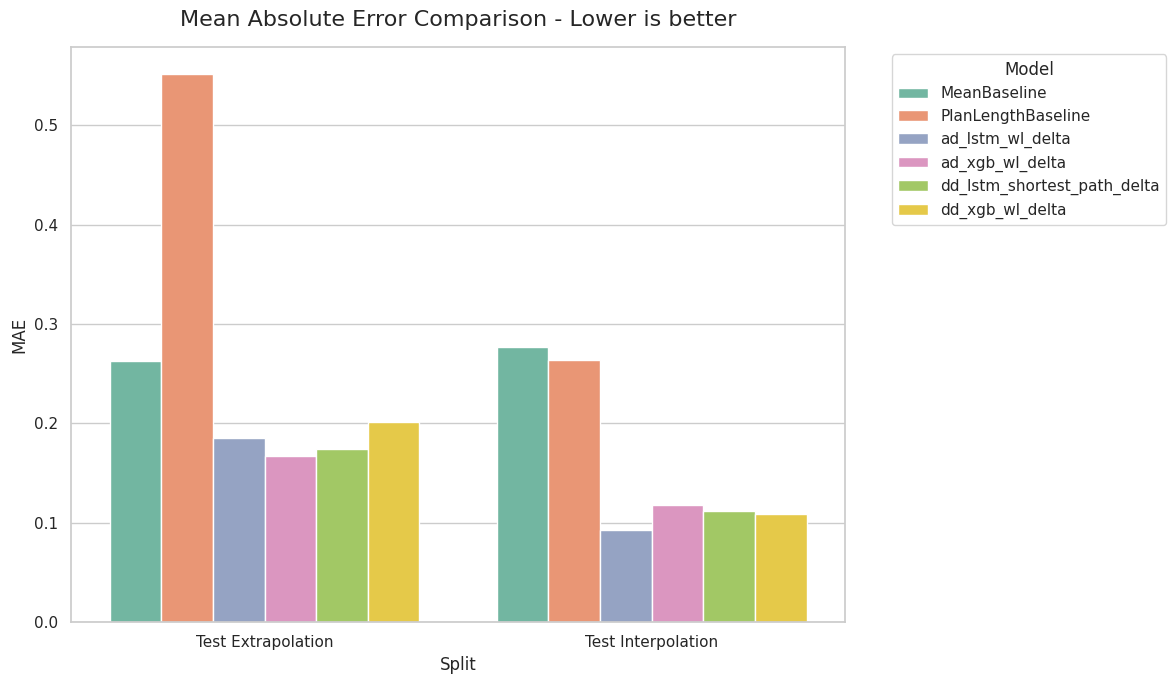

In [9]:
plt.figure(figsize=(12, 7))
ax1 = sns.barplot(
    data=df_test,
    x='split',
    y='MAE_mean',
    hue='Model',
    errorbar=None
)

plt.title('Mean Absolute Error Comparison - Lower is better', fontsize=16, pad=15)
plt.ylabel('MAE', fontsize=12)
plt.xlabel('Split', fontsize=12)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

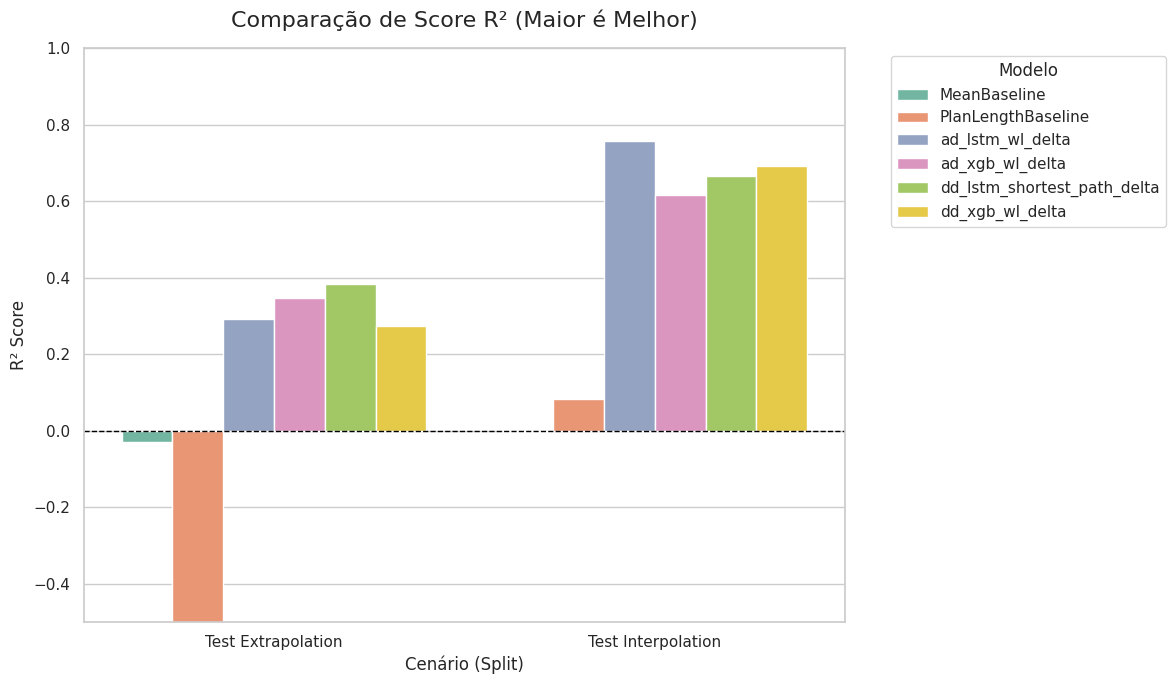

In [ ]:
plt.figure(figsize=(12, 7))
ax2 = sns.barplot(
    data=df_test,
    x='split',
    y='R2_mean',
    hue='Model',
)

plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.ylim(bottom=-0.5, top=1.0)

plt.title('R² Comparison (Higher is better)', fontsize=16, pad=15)
plt.ylabel('R² Score', fontsize=12)
plt.xlabel('Cenário (Split)', fontsize=12)
plt.legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()